<a href="https://colab.research.google.com/github/DaniloDuque/multimodal-cataract-seg/blob/main/src/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/DaniloDuque/multimodal-cataract-seg/blob/main/src/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Modal Attention Fusion for Anterior Segment Segmentation

This notebook orchestrates all experiments for the paper. It runs four models:

| Model | Description |
|-------|-------------|
| U-Net (RGB) | Standard baseline, RGB input only |
| U-Net (Edge) | Edge map input only |
| U-Net (Early Fusion) | RGB + Edge concatenated at input |
| **Proposed** | Dual encoder + bottleneck cross-attention |

Metrics reported: **IoU** (primary), Dice, F1.

---
## Environment Setup

Clones the repository if running in Colab, pulls latest changes if it already exists, and adds `src/` to the Python path.

In [1]:
## @brief Sets up the execution environment (Colab or local).
#  Clones the repository on first run; pulls latest changes on subsequent runs.
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('multimodal-cataract-seg'):
        os.system('git clone https://github.com/DaniloDuque/multimodal-cataract-seg')
    else:
        os.system('git -C multimodal-cataract-seg pull')
    os.chdir('multimodal-cataract-seg/src')

if 'src' not in sys.path:
    sys.path.insert(0, os.path.abspath('.'))

## Dependencies

In [2]:
## @brief Installs all project dependencies.
import subprocess, sys

deps = [
    'torch', 'torchvision',
    'segmentation-models-pytorch',
    'torchmetrics',
    'opencv-python',
    'albumentations',
    'roboflow',
    'python-dotenv',
    'matplotlib',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + deps, check=True)
print('✓ Dependencies installed.')

✓ Dependencies installed.


## Imports and Configuration

In [3]:
## @brief Imports all project modules and sets the random seed for reproducibility.
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

from config import CONFIG
from data.dataset import CataractSegDataset
from models.unet_baseline import UNetBaseline
from models.dual_encoder import DualEncoderUNet
from train import train
from evaluate import compute_metrics, print_results_table

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
Path(CONFIG['checkpoints_dir']).mkdir(exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(exist_ok=True)

print(f"Device: {CONFIG['device']}")

Device: cuda


---
## Dataset Download

Downloads the Cataract-Seg dataset from Roboflow using the API key stored in `.env`.
Set `RF_API_KEY` in your `.env` file before running.

In [4]:
## @brief Downloads the Cataract-Seg dataset from Roboflow in PNG masks format.
#  In Colab: reads RF_API_KEY from Colab Secrets (left sidebar → key icon).
#  Locally: reads RF_API_KEY from the .env file at the project root.
import os
from dotenv import load_dotenv
from roboflow import Roboflow

if 'google.colab' in sys.modules:
    from google.colab import userdata
    api_key = userdata.get('RF_API_KEY')
else:
    load_dotenv(dotenv_path=os.path.join('..', '.env'))
    api_key = os.environ.get('RF_API_KEY', '')

assert api_key, 'RF_API_KEY not found. Add it to Colab Secrets or your .env file.'

rf      = Roboflow(api_key=api_key)
project = rf.workspace('muhammad-risma').project('cataract-seg')
dataset = project.version(1).download('coco-segmentation', location=CONFIG['data_root'])
print(f"✓ Dataset downloaded to {CONFIG['data_root']}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/cataract-seg in coco-segmentation:: 100%|██████████| 307/307 [00:00<00:00, 7972.09it/s]

✓ Dataset downloaded to data/cataract-seg


---
## Data Loading

Builds train/valid/test datasets and dataloaders. All models share the same loaders for a fair comparison.

In [5]:
## @brief Builds train, valid, and test DataLoaders.
def make_loader(split, shuffle):
    ds = CataractSegDataset(
        data_root=CONFIG['data_root'],
        split=split,
        img_size=CONFIG['img_size'],
        canny_t1=CONFIG['canny_t1'],
        canny_t2=CONFIG['canny_t2'],
    )
    return DataLoader(ds, batch_size=CONFIG['batch_size'], shuffle=shuffle, num_workers=2)

train_loader = make_loader('train', shuffle=True)
val_loader   = make_loader('valid', shuffle=False)
test_loader  = make_loader('test',  shuffle=False)

print(f"Train: {len(train_loader.dataset)} | "
      f"Valid: {len(val_loader.dataset)} | "
      f"Test:  {len(test_loader.dataset)}")

Train: 210 | Valid: 59 | Test:  30


---
## Model Training

Four independent training runs. Each saves its best checkpoint (by validation loss) to `checkpoints/`.

In [6]:
## @brief Trains the U-Net (RGB) baseline.
model_rgb = UNetBaseline(in_channels=3).to(CONFIG['device'])
history_rgb = train(model_rgb, train_loader, val_loader, CONFIG, mode='rgb', run_name='unet_rgb')
print('✓ U-Net (RGB) trained.')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[unet_rgb] Epoch 10/100  train=0.4611  val=0.4309
[unet_rgb] Epoch 20/100  train=0.2251  val=0.2182
[unet_rgb] Epoch 30/100  train=0.1332  val=0.1398
[unet_rgb] Epoch 40/100  train=0.0879  val=0.1046
[unet_rgb] Epoch 50/100  train=0.0747  val=0.0860
[unet_rgb] Epoch 60/100  train=0.0495  val=0.0722
[unet_rgb] Epoch 70/100  train=0.0462  val=0.0767
[unet_rgb] Epoch 80/100  train=0.0525  val=0.0943
[unet_rgb] Epoch 90/100  train=0.0378  val=0.0551
[unet_rgb] Epoch 100/100  train=0.0441  val=0.0614
✓ U-Net (RGB) trained.


In [7]:
## @brief Trains the U-Net (Edge) baseline using only the Canny edge map as input.
model_edge = UNetBaseline(in_channels=3).to(CONFIG['device'])
history_edge = train(model_edge, train_loader, val_loader, CONFIG, mode='edge', run_name='unet_edge')
print('✓ U-Net (Edge) trained.')

[unet_edge] Epoch 10/100  train=0.5612  val=0.5342
[unet_edge] Epoch 20/100  train=0.3113  val=0.3121
[unet_edge] Epoch 30/100  train=0.2128  val=0.2237
[unet_edge] Epoch 40/100  train=0.1579  val=0.1851
[unet_edge] Epoch 50/100  train=0.1309  val=0.1622
[unet_edge] Epoch 60/100  train=0.1131  val=0.1393
[unet_edge] Epoch 70/100  train=0.1085  val=0.1199
[unet_edge] Epoch 80/100  train=0.0856  val=0.1083
[unet_edge] Epoch 90/100  train=0.0801  val=0.1011
[unet_edge] Epoch 100/100  train=0.0669  val=0.1028
✓ U-Net (Edge) trained.


In [8]:
## @brief Trains the early-fusion baseline (RGB + Edge concatenated at the input channel).
model_ef = UNetBaseline(in_channels=6).to(CONFIG['device'])
history_ef = train(model_ef, train_loader, val_loader, CONFIG, mode='early_fusion', run_name='unet_early_fusion')
print('✓ U-Net (Early Fusion) trained.')

[unet_early_fusion] Epoch 10/100  train=0.2568  val=0.2404
[unet_early_fusion] Epoch 20/100  train=0.1232  val=0.1363
[unet_early_fusion] Epoch 30/100  train=0.0782  val=0.1004
[unet_early_fusion] Epoch 40/100  train=0.0614  val=0.0705
[unet_early_fusion] Epoch 50/100  train=0.0516  val=0.0776
[unet_early_fusion] Epoch 60/100  train=0.0418  val=0.0795
[unet_early_fusion] Epoch 70/100  train=0.0392  val=0.0604
[unet_early_fusion] Epoch 80/100  train=0.0305  val=0.0574
[unet_early_fusion] Epoch 90/100  train=0.0252  val=0.0525
[unet_early_fusion] Epoch 100/100  train=0.0238  val=0.0547
✓ U-Net (Early Fusion) trained.


In [9]:
## @brief Trains the proposed dual-encoder model with bottleneck cross-attention fusion.
model_dual = DualEncoderUNet(
    num_classes=1,
    embed_dim=CONFIG['embed_dim'],
    num_heads=CONFIG['n_heads'],
).to(CONFIG['device'])
history_dual = train(model_dual, train_loader, val_loader, CONFIG, mode='dual', run_name='dual_encoder')
print('✓ Dual Encoder (Proposed) trained.')

[dual_encoder] Epoch 10/100  train=0.4642  val=0.4308
[dual_encoder] Epoch 20/100  train=0.2049  val=0.2154
[dual_encoder] Epoch 30/100  train=0.1190  val=0.1119
[dual_encoder] Epoch 40/100  train=0.0699  val=0.0874
[dual_encoder] Epoch 50/100  train=0.0666  val=0.0721
[dual_encoder] Epoch 60/100  train=0.0428  val=0.0633
[dual_encoder] Epoch 70/100  train=0.0624  val=0.0691
[dual_encoder] Epoch 80/100  train=0.0346  val=0.0631
[dual_encoder] Epoch 90/100  train=0.0274  val=0.0559
[dual_encoder] Epoch 100/100  train=0.0268  val=0.0570
✓ Dual Encoder (Proposed) trained.


---
## Training Curves

Loss curves (BCE + Dice) for all models over the full training run.

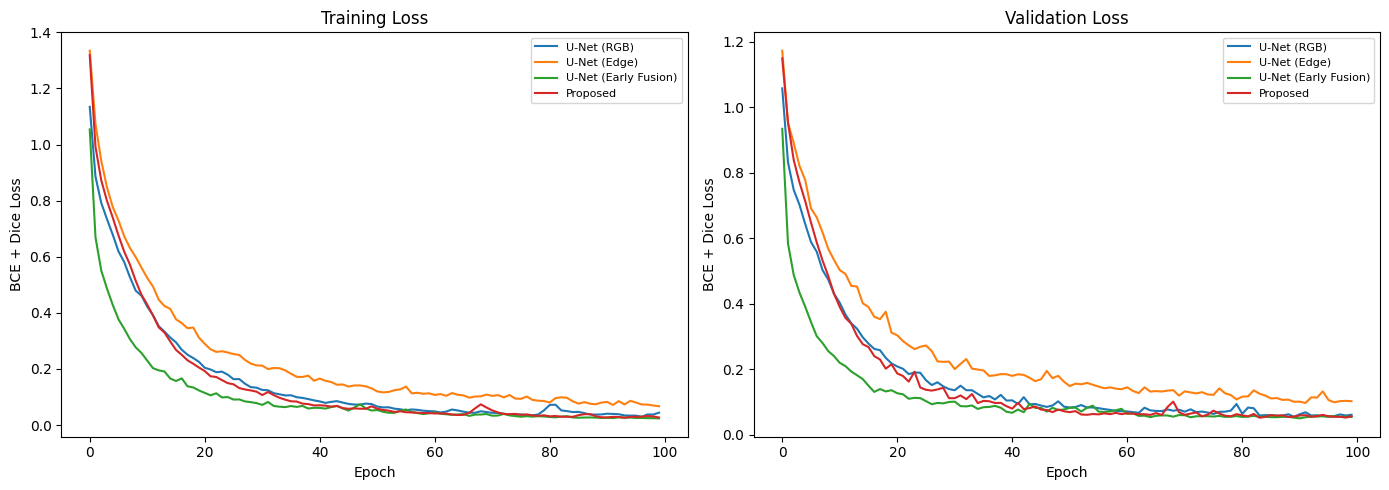

In [10]:
## @brief Plots training and validation loss curves for all four models.
histories = {
    'U-Net (RGB)':          history_rgb,
    'U-Net (Edge)':         history_edge,
    'U-Net (Early Fusion)': history_ef,
    'Proposed':             history_dual,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in histories.items():
    axes[0].plot(h['train_losses'], label=name)
    axes[1].plot(h['val_losses'],   label=name)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE + Dice Loss')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/loss_curves.pdf", bbox_inches='tight')
plt.show()

---
## Test Set Evaluation

Loads the best checkpoint for each model and evaluates on the held-out test set.

In [11]:
## @brief Loads best checkpoints and computes IoU, Dice, and F1 on the test set.
runs = [
    ('U-Net (RGB)',          model_rgb,  'unet_rgb',          'rgb'),
    ('U-Net (Edge)',         model_edge, 'unet_edge',         'edge'),
    ('U-Net (Early Fusion)', model_ef,   'unet_early_fusion', 'early_fusion'),
    ('Proposed',             model_dual, 'dual_encoder',      'dual'),
]

results = {}
for name, model, ckpt_name, mode in runs:
    ckpt = os.path.join(CONFIG['checkpoints_dir'], f'{ckpt_name}_best.pth')
    model.load_state_dict(torch.load(ckpt, map_location=CONFIG['device']))
    results[name] = compute_metrics(model, test_loader, CONFIG, mode)

print_results_table(results)


Model                    IoU      Dice        F1
U-Net (RGB)           0.9529    0.9761    0.9759
U-Net (Edge)          0.8817    0.9375    0.9371
U-Net (Early Fusion)    0.9532    0.9763    0.9761
Proposed              0.9530    0.9761    0.9759


---
## Qualitative Predictions

Visual comparison of predicted masks for a sample batch from the test set.

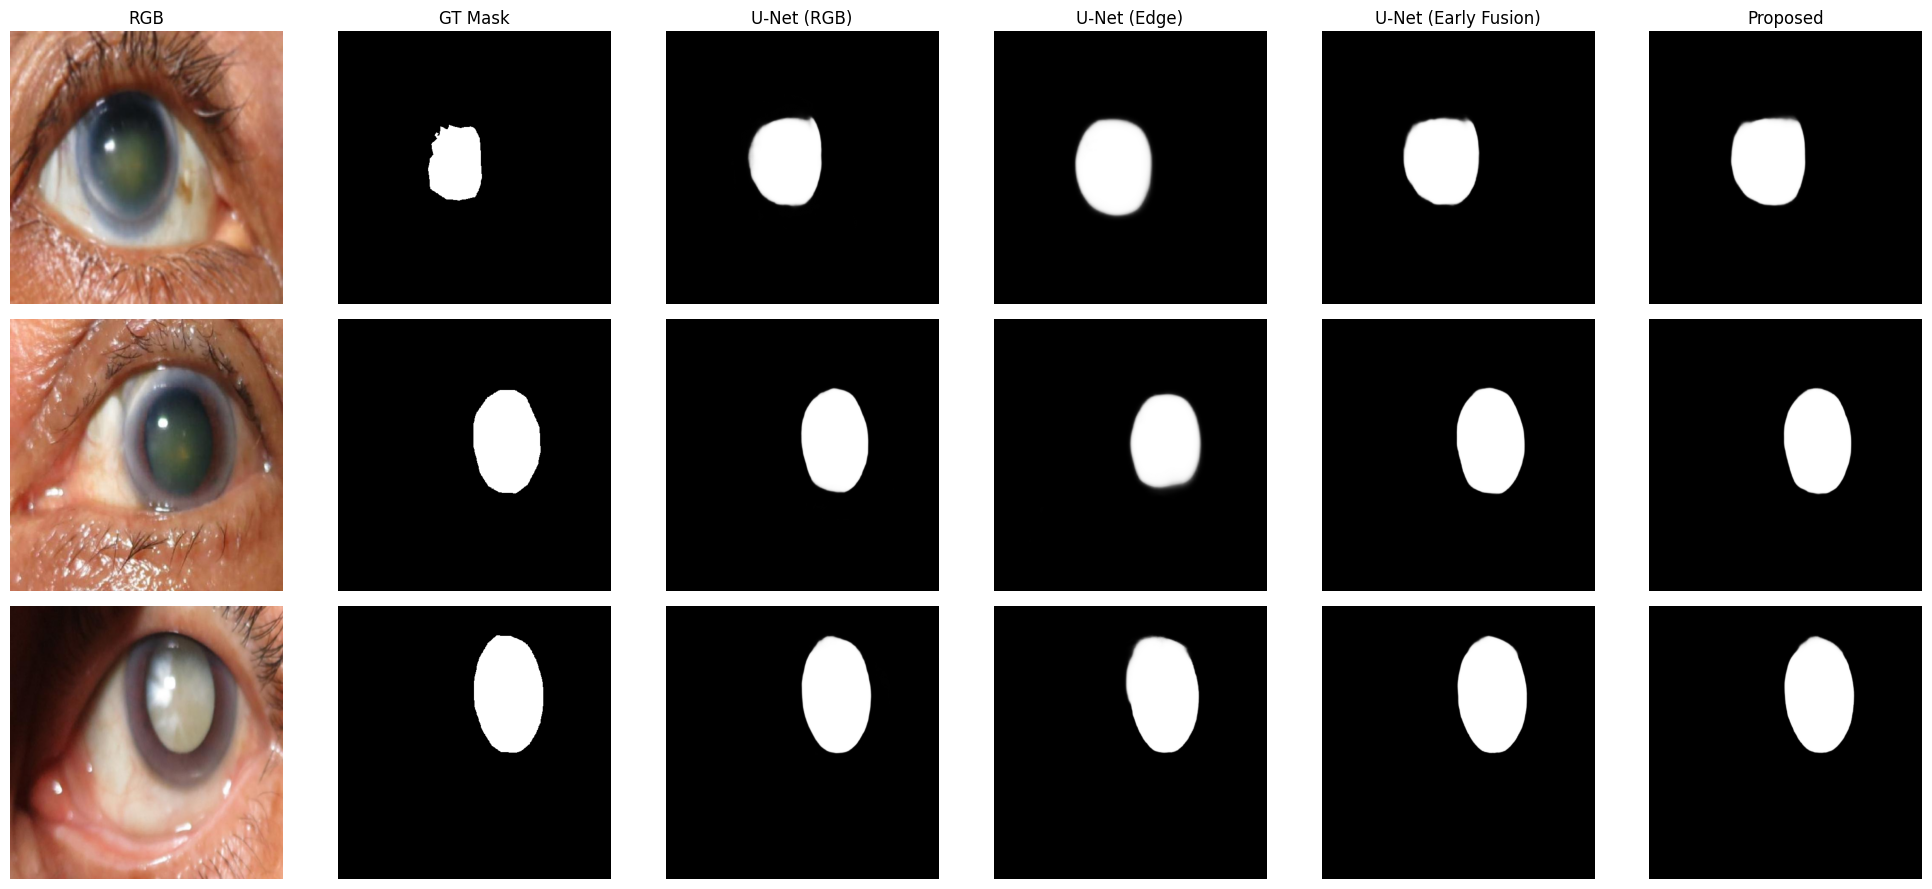

In [12]:
## @brief Visualizes predicted masks from all four models on three test images.
from train import _forward

rgb_batch, edge_batch, mask_batch = next(iter(test_loader))
rgb_batch  = rgb_batch[:3].to(CONFIG['device'])
edge_batch = edge_batch[:3].to(CONFIG['device'])
mask_batch = mask_batch[:3]

model_names = ['U-Net (RGB)', 'U-Net (Edge)', 'U-Net (Early Fusion)', 'Proposed']
mode_map    = {'U-Net (RGB)': 'rgb', 'U-Net (Edge)': 'edge',
               'U-Net (Early Fusion)': 'early_fusion', 'Proposed': 'dual'}
model_map   = {'U-Net (RGB)': model_rgb, 'U-Net (Edge)': model_edge,
               'U-Net (Early Fusion)': model_ef, 'Proposed': model_dual}

n_imgs = 3
fig, axes = plt.subplots(n_imgs, len(model_names) + 2, figsize=(20, 3 * n_imgs))

for i in range(n_imgs):
    axes[i, 0].imshow(rgb_batch[i].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[i, 0].set_title('RGB' if i == 0 else '')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(mask_batch[i, 0], cmap='gray')
    axes[i, 1].set_title('GT Mask' if i == 0 else '')
    axes[i, 1].axis('off')
    for j, name in enumerate(model_names):
        with torch.no_grad():
            pred = torch.sigmoid(_forward(model_map[name], rgb_batch[[i]], edge_batch[[i]], mode_map[name]))
        axes[i, j + 2].imshow(pred[0, 0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[i, j + 2].set_title(name if i == 0 else '')
        axes[i, j + 2].axis('off')

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/qualitative_predictions.pdf", bbox_inches='tight')
plt.show()